In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')



In [3]:
# Load training data
train_final = pd.read_csv('/home/jupyter/train_final.csv')

# Define feature columns
feature_cols = [col for col in train_final.columns 
                if col not in ['cut', 'cutter', 'max_wear']]

print(f"Dataset shape: {train_final.shape}")
print(f"Features: {feature_cols}")

Dataset shape: (945, 15)
Features: ['vib_x_std', 'vib_x_max', 'force_x_p2p', 'force_y_mean', 'force_x_max', 'vib_y_std', 'force_y_max', 'vib_x_kurtosis', 'vib_y_kurtosis', 'force_y_kurtosis', 'force_y_skewness', 'force_x_kurtosis']


In [4]:
# Define baseline period - first 50 cuts per cutter
def compute_baseline(cutter_df, ctq='force_y_mean', baseline_cuts=50):
    """
    Compute baseline statistics from first N cuts
    Returns mean, std, USL, LSL
    """
    baseline = cutter_df[cutter_df['cut'] <= baseline_cuts][ctq]
    
    mean = baseline.mean()
    std = baseline.std()
    
    USL = mean + 3 * std
    LSL = mean - 3 * std
    
    print(f"Baseline statistics:")
    print(f"  Mean: {mean:.4f}")
    print(f"  Std:  {std:.4f}")
    print(f"  USL:  {USL:.4f}")
    print(f"  LSL:  {LSL:.4f}")
    
    return mean, std, USL, LSL

# Compute baseline for each training cutter
print("=== C1 Baseline ===")
mean_c1, std_c1, USL_c1, LSL_c1 = compute_baseline(
    train_final[train_final['cutter']=='c1'])

print("\n=== C4 Baseline ===")
mean_c4, std_c4, USL_c4, LSL_c4 = compute_baseline(
    train_final[train_final['cutter']=='c4'])

print("\n=== C6 Baseline ===")
mean_c6, std_c6, USL_c6, LSL_c6 = compute_baseline(
    train_final[train_final['cutter']=='c6'])

=== C1 Baseline ===
Baseline statistics:
  Mean: 2.9057
  Std:  0.5957
  USL:  4.6928
  LSL:  1.1186

=== C4 Baseline ===
Baseline statistics:
  Mean: 3.2727
  Std:  0.7385
  USL:  5.4881
  LSL:  1.0572

=== C6 Baseline ===
Baseline statistics:
  Mean: 3.5839
  Std:  0.7575
  USL:  5.8565
  LSL:  1.3113


In [5]:
# Compute rolling Cp/Cpk
def compute_rolling_cpk(cutter_df, mean_baseline, USL, LSL, 
                         ctq='force_y_mean', window=20):
    """
    Computes rolling Cp and Cpk using a sliding window of cuts
    window: number of cuts to include in each calculation
    """
    values = cutter_df[ctq].values
    cuts = cutter_df['cut'].values
    
    cp_values = []
    cpk_values = []
    
    for i in range(len(values)):
        # Get window of values
        start = max(0, i - window + 1)
        window_vals = values[start:i+1]
        
        if len(window_vals) < 5:
            cp_values.append(np.nan)
            cpk_values.append(np.nan)
            continue
        
        # Compute rolling std
        rolling_std = np.std(window_vals, ddof=1)
        rolling_mean = np.mean(window_vals)
        
        if rolling_std == 0:
            cp_values.append(np.nan)
            cpk_values.append(np.nan)
            continue
        
        # Cp - process spread capability
        cp = (USL - LSL) / (6 * rolling_std)
        
        # Cpk - process centering capability
        cpu = (USL - rolling_mean) / (3 * rolling_std)
        cpl = (rolling_mean - LSL) / (3 * rolling_std)
        cpk = min(cpu, cpl)
        
        cp_values.append(cp)
        cpk_values.append(cpk)
    
    return cuts, np.array(cp_values), np.array(cpk_values)

# Compute for each cutter
cuts_c1, cp_c1, cpk_c1 = compute_rolling_cpk(
    train_final[train_final['cutter']=='c1'], mean_c1, USL_c1, LSL_c1)

cuts_c4, cp_c4, cpk_c4 = compute_rolling_cpk(
    train_final[train_final['cutter']=='c4'], mean_c4, USL_c4, LSL_c4)

cuts_c6, cp_c6, cpk_c6 = compute_rolling_cpk(
    train_final[train_final['cutter']=='c6'], mean_c6, USL_c6, LSL_c6)

print("Rolling Cp/Cpk computed")
print(f"\nC1 final Cpk: {cpk_c1[-1]:.3f}")
print(f"C4 final Cpk: {cpk_c4[-1]:.3f}")
print(f"C6 final Cpk: {cpk_c6[-1]:.3f}")

Rolling Cp/Cpk computed

C1 final Cpk: -3.257
C4 final Cpk: -3.330
C6 final Cpk: -3.861


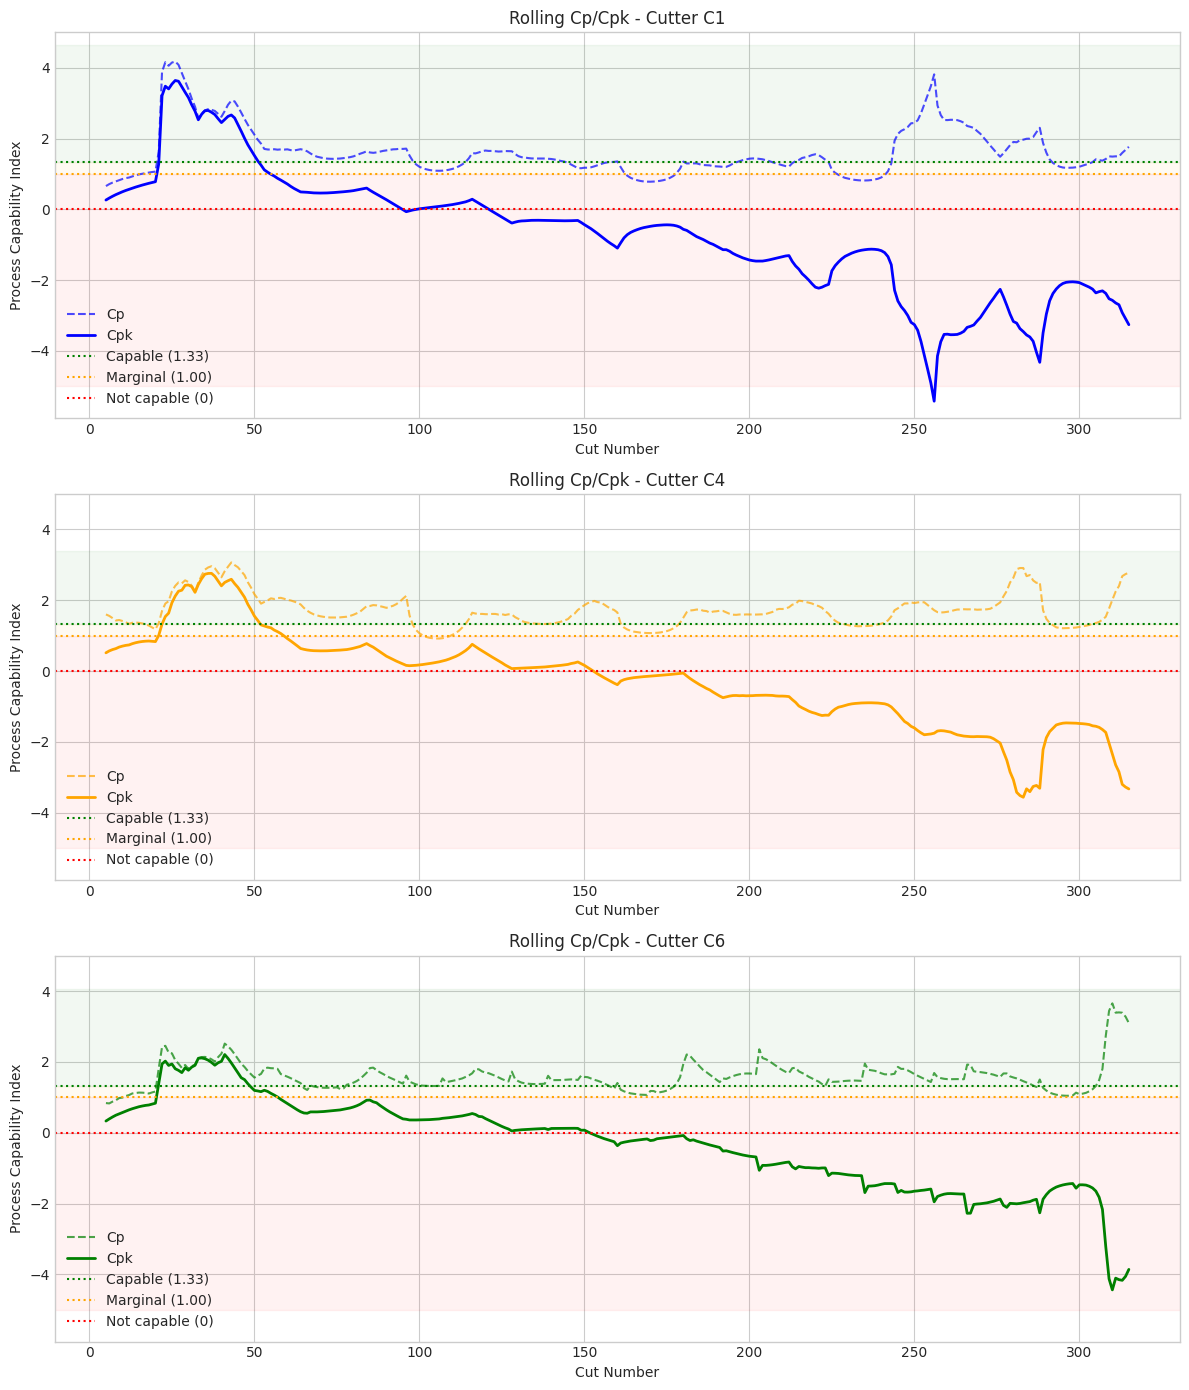

Plot saved


In [9]:
# Plot rolling Cp/Cpk for all three cutters
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

cutters = ['c1', 'c4', 'c6']
cuts_list = [cuts_c1, cuts_c4, cuts_c6]
cp_list = [cp_c1, cp_c4, cp_c6]
cpk_list = [cpk_c1, cpk_c4, cpk_c6]
colors = {'c1': 'blue', 'c4': 'orange', 'c6': 'green'}

for ax, cutter, cuts, cp, cpk in zip(axes, cutters, cuts_list, cp_list, cpk_list):
    ax.plot(cuts, cp, color=colors[cutter], linewidth=1.5,
            linestyle='--', label='Cp', alpha=0.7)
    ax.plot(cuts, cpk, color=colors[cutter], linewidth=2, label='Cpk')
    
    # Reference lines
    ax.axhline(y=1.33, color='green', linestyle=':', 
               linewidth=1.5, label='Capable (1.33)')
    ax.axhline(y=1.00, color='orange', linestyle=':', 
               linewidth=1.5, label='Marginal (1.00)')
    ax.axhline(y=0.00, color='red', linestyle=':', 
               linewidth=1.5, label='Not capable (0)')
    
    # Shade regions
    ax.axhspan(1.33, ax.get_ylim()[1] if not np.isnan(cp).all() else 3, 
               alpha=0.05, color='green')
    ax.axhspan(1.00, 1.33, alpha=0.05, color='orange')
    ax.axhspan(-5, 1.00, alpha=0.05, color='red')
    
    ax.set_title(f'Rolling Cp/Cpk - Cutter {cutter.upper()}')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Process Capability Index')
    ax.set_ylim(-5.9, 5)
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/rolling_cpk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [14]:
def compute_cusum(values, target_mean, k_factor=0.5, h_threshold=10.0):
    """
    Computes CUSUM control chart
    
    values:       CTQ measurements (force_y_mean per cut)
    target_mean:  baseline mean from first 50 cuts
    k_factor:     allowance - how much deviation we tolerate per cut
    h_threshold:  alarm threshold - increased to 10 to reduce false alarms
    """
    std = np.std(values[:50])  # baseline std
    k = k_factor * std         # allowance in original units
    h = h_threshold * std      # threshold in original units
    
    cusum_pos = np.zeros(len(values))
    cusum_neg = np.zeros(len(values))
    alerts = np.zeros(len(values))
    
    for i in range(1, len(values)):
        cusum_pos[i] = max(0, cusum_pos[i-1] + (values[i] - target_mean) - k)
        cusum_neg[i] = min(0, cusum_neg[i-1] + (values[i] - target_mean) + k)
        
        if cusum_pos[i] > h or cusum_neg[i] < -h:
            alerts[i] = 1
    
    return cusum_pos, cusum_neg, alerts, h



In [15]:
# Run CUSUM on all three training cutters
def run_cusum_cutter(cutter_df, target_mean, ctq='force_y_mean'):
    values = cutter_df[ctq].values
    cuts = cutter_df['cut'].values
    cusum_pos, cusum_neg, alerts, h = compute_cusum(values, target_mean)
    
    # Find first alert cut
    alert_cuts = np.where(alerts == 1)[0]
    first_alert = cuts[alert_cuts[0]] if len(alert_cuts) > 0 else None
    
    return cuts, values, cusum_pos, cusum_neg, alerts, h, first_alert

# Run for each cutter
cuts_c1, vals_c1, cp_pos_c1, cp_neg_c1, alerts_c1, h_c1, fa_c1 = run_cusum_cutter(
    train_final[train_final['cutter']=='c1'], mean_c1)

cuts_c4, vals_c4, cp_pos_c4, cp_neg_c4, alerts_c4, h_c4, fa_c4 = run_cusum_cutter(
    train_final[train_final['cutter']=='c4'], mean_c4)

cuts_c6, vals_c6, cp_pos_c6, cp_neg_c6, alerts_c6, h_c6, fa_c6 = run_cusum_cutter(
    train_final[train_final['cutter']=='c6'], mean_c6)

print(f"C1 first drift alert at cut: {fa_c1}")
print(f"C4 first drift alert at cut: {fa_c4}")
print(f"C6 first drift alert at cut: {fa_c6}")

C1 first drift alert at cut: 52
C4 first drift alert at cut: 52
C6 first drift alert at cut: 53


In [16]:
# Check wear level at first alert for each cutter
wear_c1 = pd.read_csv('/home/jupyter/milling/c1/c1_wear.csv',
                       header=0, names=['cut','flute_1','flute_2','flute_3'])
wear_c4 = pd.read_csv('/home/jupyter/milling/c4/c4_wear.csv',
                       header=0, names=['cut','flute_1','flute_2','flute_3'])
wear_c6 = pd.read_csv('/home/jupyter/milling/c6/c6_wear.csv',
                       header=0, names=['cut','flute_1','flute_2','flute_3'])

for wear_df in [wear_c1, wear_c4, wear_c6]:
    for col in ['cut','flute_1','flute_2','flute_3']:
        wear_df[col] = pd.to_numeric(wear_df[col], errors='coerce')
    wear_df['max_wear'] = wear_df[['flute_1','flute_2','flute_3']].max(axis=1)

# Check wear at alert cuts
for cutter, wear_df, first_alert in [('C1', wear_c1, fa_c1),
                                       ('C4', wear_c4, fa_c4),
                                       ('C6', wear_c6, fa_c6)]:
    wear_at_alert = wear_df[wear_df['cut']==first_alert]['max_wear'].values
    if len(wear_at_alert) > 0:
        print(f"{cutter} - Alert at cut {first_alert}, wear = {wear_at_alert[0]:.1f} (10⁻³ mm)")

C1 - Alert at cut 52, wear = 90.6 (10⁻³ mm)
C4 - Alert at cut 52, wear = 72.4 (10⁻³ mm)
C6 - Alert at cut 53, wear = 101.8 (10⁻³ mm)


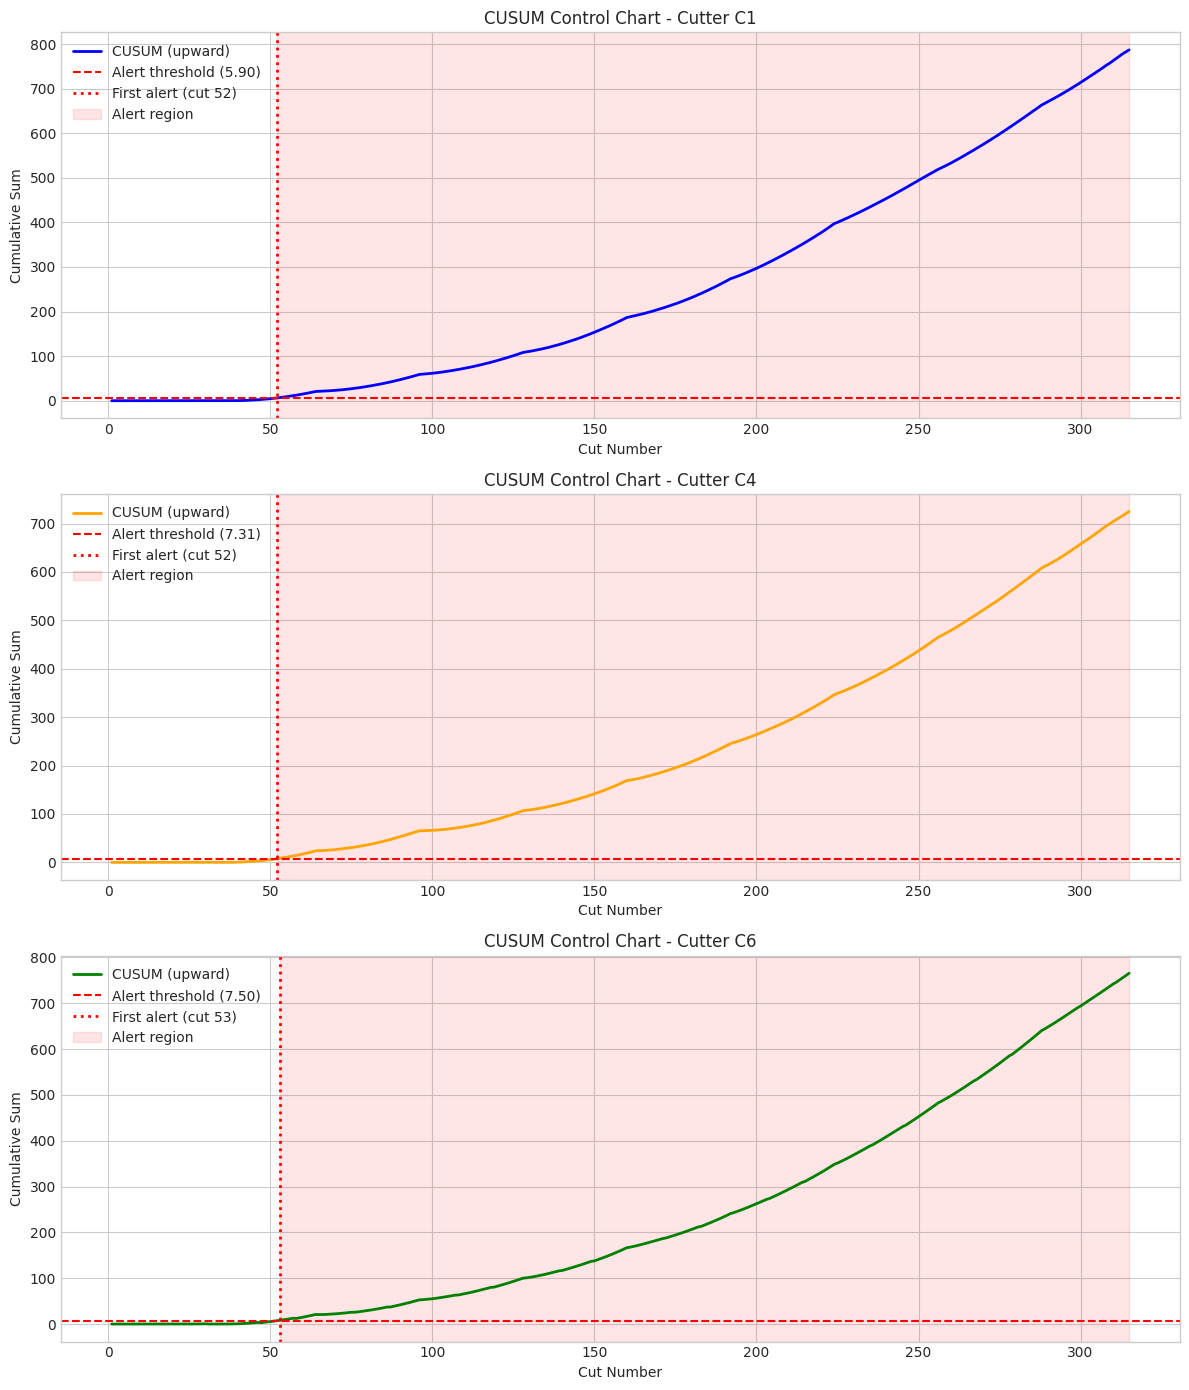

Plot saved


In [17]:
# Plot CUSUM charts for all three cutters
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

cutters = ['c1', 'c4', 'c6']
cuts_list = [cuts_c1, cuts_c4, cuts_c6]
cusum_pos_list = [cp_pos_c1, cp_pos_c4, cp_pos_c6]
alerts_list = [alerts_c1, alerts_c4, alerts_c6]
first_alerts = [fa_c1, fa_c4, fa_c6]
h_list = [h_c1, h_c4, h_c6]
colors = {'c1': 'blue', 'c4': 'orange', 'c6': 'green'}

for ax, cutter, cuts, cusum_pos, alerts, fa, h in zip(
        axes, cutters, cuts_list, cusum_pos_list, 
        alerts_list, first_alerts, h_list):
    
    # Plot CUSUM
    ax.plot(cuts, cusum_pos, color=colors[cutter], 
            linewidth=2, label='CUSUM (upward)')
    
    # Plot threshold
    ax.axhline(y=h, color='red', linestyle='--', 
               linewidth=1.5, label=f'Alert threshold ({h:.2f})')
    
    # Mark first alert
    if fa is not None:
        ax.axvline(x=fa, color='red', linestyle=':', 
                   linewidth=2, label=f'First alert (cut {fa})')
    
    # Shade alert region
    alert_cuts = cuts[alerts == 1]
    if len(alert_cuts) > 0:
        ax.axvspan(alert_cuts[0], cuts[-1], 
                   alpha=0.1, color='red', label='Alert region')
    
    ax.set_title(f'CUSUM Control Chart - Cutter {cutter.upper()}')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Cumulative Sum')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/cusum_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [19]:
# Save plots to bucket
!gsutil -m cp -r /home/jupyter/plots/* gs://phm2010-data-temilola/plots/
print("Plots uploaded")

Copying file:///home/jupyter/plots/c1_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/all_cutters_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/correlation_heatmap.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/cusum_charts.png [Content-Type=image/png]... 
Copying file:///home/jupyter/plots/features_vs_wear.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/kalman_filter_results.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/gb_smoothed_predictions.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/gb_predictions.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/method_comparison.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/model_comparison.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/sample_sensor_signals.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/physics_pr